<a href="https://colab.research.google.com/github/yemioz/Numerical-Methods-Projects/blob/main/interpolation-direct-method-lienar-spline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interpolation

This notebook implements interpolation using both the direct-method and linear spline from scratch. 

Below are imported packages that will support the functions and expressions needed for the coding throughout this project.

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

### Background Information


Below is our functions and the Gauss-Jordan algorithm from Project Part 4. We integrated our functions with Dr. Jacob's algorithm since we were unsuccessful in our attempts to create one.

In [ ]:
def swap_rows(matrix, row1, row2):
  new_matrix = []
  for i in range(len(matrix)):
    if i != row1:
      if i != row2:
        new_matrix.append(matrix[i,:])
      else:
        new_matrix.append(matrix[row1,:])
    else:
      new_matrix.append(matrix[row2,:])
  return np.array(new_matrix)


def add_rows(matrix, target_row, modifier_row, value):
  new_row = matrix[target_row,:] + value*matrix[modifier_row,:]
  new_matrix = []
  for i in range(len(matrix)):
    if i != target_row:
      new_matrix.append(matrix[i,:])
    else:
      new_matrix.append(new_row)
  return np.array(new_matrix)


def leading_one(matrix,row,column):
  new_matrix =[]
  for i in range(len(matrix)):
    if i != row:
      new_matrix.append(matrix[i,:])
    else:
      new_matrix.append(1/matrix[row,column]*matrix[row,:])
  return np.array(new_matrix)

In [ ]:
def largest_pivot(matrix, column):
  vec = matrix[column:,column]
  vec = np.abs(vec)
  row = np.where(vec == max(vec))
  return row[0][0]+column

def gauss_jordan(matrix):
  new_matrix = matrix
  for pivot in range(len(matrix)):
    new_pivot = largest_pivot(new_matrix,pivot)
    new_matrix = swap_rows(new_matrix,new_pivot,pivot)
    new_matrix = leading_one(new_matrix,pivot,pivot)
    for column in range(0,pivot):
      new_matrix = add_rows(new_matrix,column,pivot,-new_matrix[column,pivot])
    for column in range(pivot+1,len(matrix)):
      new_matrix = add_rows(new_matrix,column,pivot,-new_matrix[column,pivot])
  return new_matrix

### Direct Method

Our chosen expression is:
$$4e^{-x}$$
The direct method interpolation is given by the formula below: $$y=a_{0}+a_{1}x+.......+a_{n}x^{n}$$
We will use the points $(-2,29.55622),(-0.5,6.59488),(0,4),(1,1.47151),(2,0.54134)$ to create a polynomial.


In [ ]:
data = [[1, 1.47151], [2, 0.54134], [0, 4], [-2, 29.55622], [-.5, 6.59488]]
matrix = np.array([[1,1,1,1,1,1.47151],[16,8,4,2,1,.54134],[0,0,0,0,1,4],[16,-8,4,-2,1,29.55622],[.0625,-.125,.25,-.5,1,6.59488]])

In [ ]:
gauss_jordan(matrix)

array([[ 1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.17622467],
       [ 0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
        -0.83056967],
       [ 0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         2.05729633],
       [ 0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        -3.93144133],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         4.        ]])

Therefore our polynomial is: $y=0.17622467x^{4}-0.83056967x^{3}+2.05729633x^{2}-3.93144133x+4$

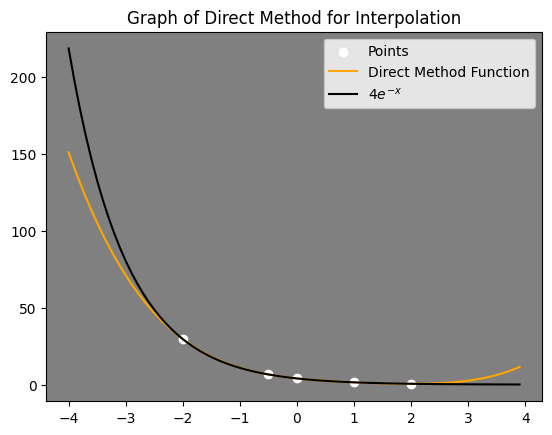

In [ ]:
direct_method_function = lambda x: 0.17622467*x**4 - 0.83056967*x**3 + 2.05729633*x**2 - 3.93144133*x + 4
input = [1, 2, 0, -2, -.5]
output = [1.47151, 0.54134, 4, 29.55622, 6.59488]

x = np.arange(-4, 4, .1)
ax = plt.axes()
ax.set_facecolor('grey')

plt.scatter(input, output, c='white')
plt.plot(x, direct_method_function(x), c='orange')
plt.plot(x, 4*np.exp(-x), c='black')
plt.title('Graph of Direct Method for Interpolation')
plt.legend(['Points','Direct Method Function', '$4e^{-x}$'])

plt.show()

Graphed above are the polnomial we created, our points, and our original function $4e^{-x}$.

### Linear Spline

Here, we have created a function for a linear spline.

In [ ]:
function = lambda x: 4*math.exp(-x)
interval = [-3, 3]
points_on_interval = [-3, -1.5, 0, 2.5, 3]

def linear_spline(function, points, input):
  for i in range(len(points)-1):
    if (input > points[i]) & (input < points[i+1]):
      approx = function(points[i])+((function(points[i+1])-function(points[i]))/(points[i+1]-points[i]))*(input-points[i])
      return approx
    else:
      continue

linear_spline(function, points_on_interval, 1)

2.531335997798238

We will now use our spline to estimate our function $4e^{-x}$ on an interval utilizing $5$ points. Below is a graph showing the spline, our function, and our points.

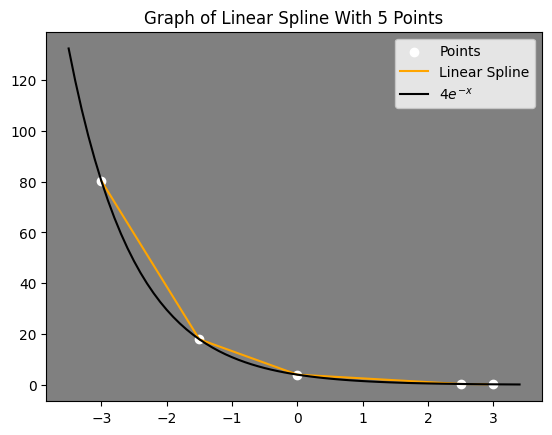

In [ ]:
output = [function(i) for i in points_on_interval]

x = np.arange(-3.5, 3.5, .1)
y = [linear_spline(function, points_on_interval, x) for x in x]

ax = plt.axes()
ax.set_facecolor('grey')
plt.scatter(points_on_interval,output,c='white')
plt.plot(x, y, c='orange')
plt.plot(x, 4*np.exp(-x), c='black')
plt.title('Graph of Linear Spline With 5 Points')
plt.legend(['Points','Linear Spline', '$4e^{-x}$'])

plt.show()

We will now do the same utilizing $20$ points. Below is a function for generating $20$ points in our interval.

In [ ]:
def even_divisors(lower_bound, upper_bound, splits):
  array = [lower_bound]
  step_size = (upper_bound - lower_bound)/(splits)
  for i in range(splits):
    array.append(lower_bound+i*step_size)
  return array

twenty_points = even_divisors(-5, 5, 20)

In [ ]:
output = [function(i) for i in twenty_points]

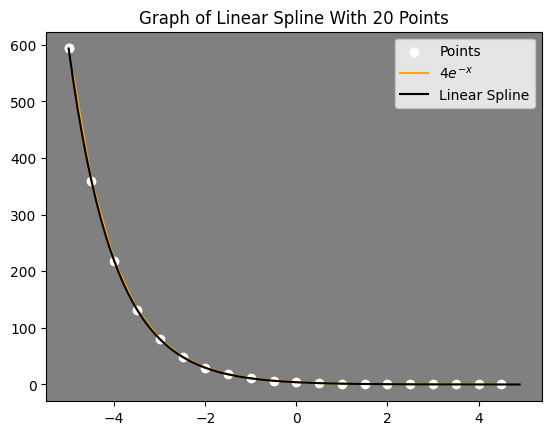

In [ ]:
x = np.arange(-5, 5, 0.1)
y = [linear_spline(function, twenty_points, x) for x in x]

output = [function(i) for i in twenty_points]
ax = plt.axes()
ax.set_facecolor('grey')
plt.scatter(twenty_points, output, c='white')
plt.plot(x, y, c='orange')
plt.plot(x, 4*np.exp(-x), c='black')
plt.title('Graph of Linear Spline With 20 Points')
plt.legend(['Points', '$4e^{-x}$', 'Linear Spline'])

plt.show()

### Findings

As seen above, the more points used when finding a spline, the closer it looks to your original expression. This would also be true of a non-linear spline, though that is not seen above.

You can see in the linear spline with 20 points that the spline becomes innacurate in places where the $y$ values between 2 increments of $x$ are vastly different. The length of the spline between -4.5 and -4.25 is greater than between 4 and 4.25 at the end, leading to a greater chance of deviation from our non-linear expression. If we were to generate another point halfway between -4.5 and -4.25, our spline would become much more accurate.

When looking at our non-linear spline, you can see that it immediately deviates from our chosen expression when it leaves the space of our chosen increments. It's safe to say that choosing an $x$ value far away from our increments and comparing the $y$ values of our expression and our spline would result in 2 wildly different values. I think how far you should go for a particular expression changes greatly based on your need for accuracy, but I doubt our non-linear spline above would be a good approximation in any field.